In [1]:
# pytorch

In [2]:
import numpy as np

# xor problem
# 0 0 -> 0
# 0 1 -> 1
# 1 0 -> 1
# 1 1 -> 0

X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y = np.array([[0], [1], [1], [0]])

input_layer_size = 2
hidden_layer_size = 3
output_layer_size = 1

In [3]:
weights_input_hidden = np.random.uniform(-1, 1, (input_layer_size, hidden_layer_size))
bias_input_hidden = np.random.uniform(-1, 1, hidden_layer_size)


weights_input_hidden, bias_input_hidden

(array([[-0.51596732, -0.57059828,  0.73040984],
        [ 0.74346315,  0.7644426 , -0.36780104]]),
 array([-0.15890827,  0.93469752, -0.88154105]))

In [4]:
weights_hidden_output = np.random.uniform(-1, 1, (hidden_layer_size, output_layer_size))
bias_hidden_output = np.random.uniform(-1, 1, output_layer_size)

weights_hidden_output, bias_hidden_output

(array([[-0.89183544],
        [ 0.23194919],
        [-0.82198876]]),
 array([-0.16050368]))

In [5]:
epochs = 10000
learning_rate = 0.1

In [6]:
for epoch in range(epochs):
    # forward pass
    hidden_layer_input = np.dot(X, weights_input_hidden) + bias_input_hidden
    hidden_layer_output = 1 / (1 + np.exp(-hidden_layer_input))  # sigmoid activation

    output_layer_input = (
        np.dot(hidden_layer_output, weights_hidden_output) + bias_hidden_output
    )
    predicted_output = 1 / (1 + np.exp(-output_layer_input))  # sigmoid activation

    # calculate error
    error = predicted_output - y

    # backpropagation
    d_predicted_output = error * (
        predicted_output * (1 - predicted_output)
    )  # derivative of sigmoid
    error_hidden_layer = d_predicted_output.dot(weights_hidden_output.T)
    d_hidden_layer = error_hidden_layer * (
        hidden_layer_output * (1 - hidden_layer_output)
    )  # derivative of sigmoid

    # update weights and biases
    weights_hidden_output -= (
        hidden_layer_output.T.dot(d_predicted_output) * learning_rate
    )
    bias_hidden_output -= np.sum(d_predicted_output, axis=0) * learning_rate
    weights_input_hidden -= X.T.dot(d_hidden_layer) * learning_rate
    bias_input_hidden -= np.sum(d_hidden_layer, axis=0) * learning_rate

In [7]:
# prediction after training
hidden_layer_input = np.dot(X, weights_input_hidden) + bias_input_hidden
hidden_layer_output = 1 / (1 + np.exp(-hidden_layer_input))  # sigmoid activation

output_layer_input = (
    np.dot(hidden_layer_output, weights_hidden_output) + bias_hidden_output
)
predicted_output = 1 / (1 + np.exp(-output_layer_input))  # sigmoid activation

print("Predicted output after training:")
print(predicted_output)

Predicted output after training:
[[0.03039904]
 [0.9328108 ]
 [0.93882769]
 [0.07771246]]


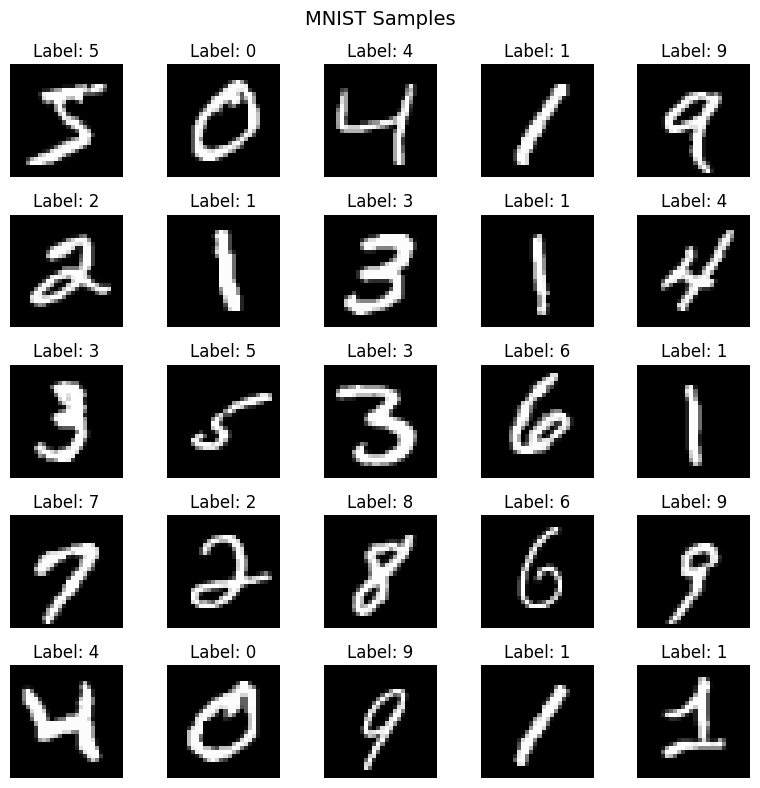

In [8]:
import torch
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# Download MNIST dataset
transform = transforms.ToTensor()
train_mnist = datasets.MNIST(
    root="./data", train=True, download=True, transform=transform
)
test_mnist = datasets.MNIST(
    root="./data", train=False, download=True, transform=transform
)

# Show a grid of 25 sample images
fig, axes = plt.subplots(5, 5, figsize=(8, 8))
for i, ax in enumerate(axes.flat):
    img, label = train_mnist[i]
    ax.imshow(img.squeeze(), cmap="gray")
    ax.set_title(f"Label: {label}")
    ax.axis("off")

plt.suptitle("MNIST Samples", fontsize=14)
plt.tight_layout()
plt.show()


In [9]:
train_loader = torch.utils.data.DataLoader(train_mnist, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_mnist, batch_size=64, shuffle=False)

In [10]:
class FFNN(torch.nn.Module):
    def __init__(self):
        super(FFNN, self).__init__()
        self.fc1 = torch.nn.Linear(28 * 28, 128)
        self.fc2 = torch.nn.Linear(128, 64)
        self.fc3 = torch.nn.Linear(64, 10)

    def forward(self, x):
        x = x.view(-1, 28 * 28)  # flatten the input
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [11]:
epochs = 3
batch_size = 64
learning_rate = 0.001

In [12]:
model = FFNN()

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

In [13]:
for epoch in range(epochs):
    for b_idx, (images, labels) in enumerate(train_loader):
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        if (b_idx + 1) % 100 == 0:
            print(
                f"Epoch [{epoch + 1}/{epochs}], Step [{b_idx + 1}/{len(train_loader)}], Loss: {loss.item():.4f}"
            )


Epoch [1/3], Step [100/938], Loss: 0.6065
Epoch [1/3], Step [200/938], Loss: 0.3235
Epoch [1/3], Step [300/938], Loss: 0.2558
Epoch [1/3], Step [400/938], Loss: 0.1898
Epoch [1/3], Step [500/938], Loss: 0.0973
Epoch [1/3], Step [600/938], Loss: 0.1180
Epoch [1/3], Step [700/938], Loss: 0.2076
Epoch [1/3], Step [800/938], Loss: 0.3427
Epoch [1/3], Step [900/938], Loss: 0.1454
Epoch [2/3], Step [100/938], Loss: 0.1065
Epoch [2/3], Step [200/938], Loss: 0.1636
Epoch [2/3], Step [300/938], Loss: 0.2521
Epoch [2/3], Step [400/938], Loss: 0.1103
Epoch [2/3], Step [500/938], Loss: 0.0377
Epoch [2/3], Step [600/938], Loss: 0.1360
Epoch [2/3], Step [700/938], Loss: 0.2142
Epoch [2/3], Step [800/938], Loss: 0.2366
Epoch [2/3], Step [900/938], Loss: 0.1576
Epoch [3/3], Step [100/938], Loss: 0.0687
Epoch [3/3], Step [200/938], Loss: 0.0843
Epoch [3/3], Step [300/938], Loss: 0.0876
Epoch [3/3], Step [400/938], Loss: 0.1076
Epoch [3/3], Step [500/938], Loss: 0.2640
Epoch [3/3], Step [600/938], Loss:

In [14]:
# test inference
model.eval()

with torch.no_grad():
    correct = 0
    total = 0
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    print(f"Test Accuracy: {100 * correct / total:.2f}%")

Test Accuracy: 96.59%


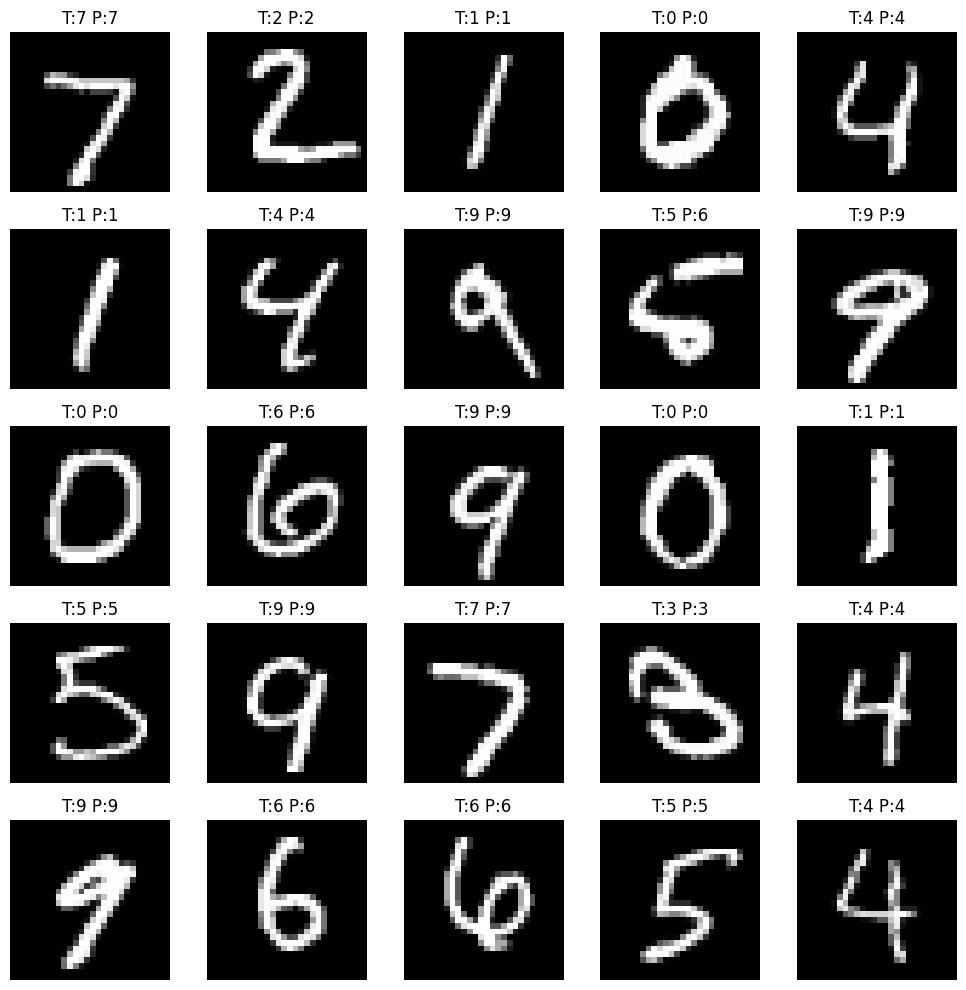

In [15]:
# matplotlib samples from test with predictions
model.eval()
fig, axes = plt.subplots(5, 5, figsize=(10, 10))

with torch.no_grad():
    for i, ax in enumerate(axes.flat):
        img, label = test_mnist[i]
        output = model(img.unsqueeze(0))
        pred = torch.argmax(output, dim=1).item()

        ax.imshow(img.squeeze(), cmap="gray")
        ax.set_title(f"T:{label} P:{pred}")
        ax.axis("off")

plt.tight_layout()
plt.show()